# Analyse Exploratoire — Dataset FAQ Restauration Rapide

Ce notebook analyse le dataset de questions/réponses utilisé par le chatbot FAQ.
Il couvre la distribution des catégories, la longueur des questions et réponses,
et la couverture thématique du dataset.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('../data/faq_dataset.csv')
print(f'Dataset chargé : {len(df)} questions, {df["categorie"].nunique()} catégories')
df.head()

Dataset chargé : 49 questions, 9 catégories


,id,categorie,question,reponse
0,1,menu,Quels sont les burgers disponibles ?,"Nous proposons plusieurs burgers : Giant, Baco..."
1,2,menu,Est-ce que vous avez des menus végétariens ?,Oui nous proposons des options végétariennes c...
2,3,menu,Quels sont les accompagnements disponibles ?,"Vous pouvez choisir entre frites classiques, p..."
3,4,menu,Est-ce que vous avez des desserts ?,"Oui nous proposons des sundaes, muffins et aut..."
4,5,menu,Quelles sont les boissons disponibles ?,"Nous proposons des sodas, jus de fruits, eau, ..."


## 1. Aperçu général du dataset

In [9]:
print('=== Informations générales ===')
print(f'Nombre total de questions : {len(df)}')
print(f'Nombre de catégories : {df["categorie"].nunique()}')
print(f'Catégories : {list(df["categorie"].unique())}')
print()
print('=== Valeurs manquantes ===')
print(df.isnull().sum())
print()
print('=== Types de données ===')
print(df.dtypes)

=== Informations générales ===
Nombre total de questions : 49
Nombre de catégories : 9
Catégories : ['menu', 'allergenes', 'horaires', 'commande', 'paiement', 'promotions', 'reclamation', 'restaurant', 'nouveautés']

=== Valeurs manquantes ===
id           0
categorie    0
question     0
reponse      0
dtype: int64

=== Types de données ===
id           int64
categorie      str
question       str
reponse        str
dtype: object


## 2. Distribution par catégorie

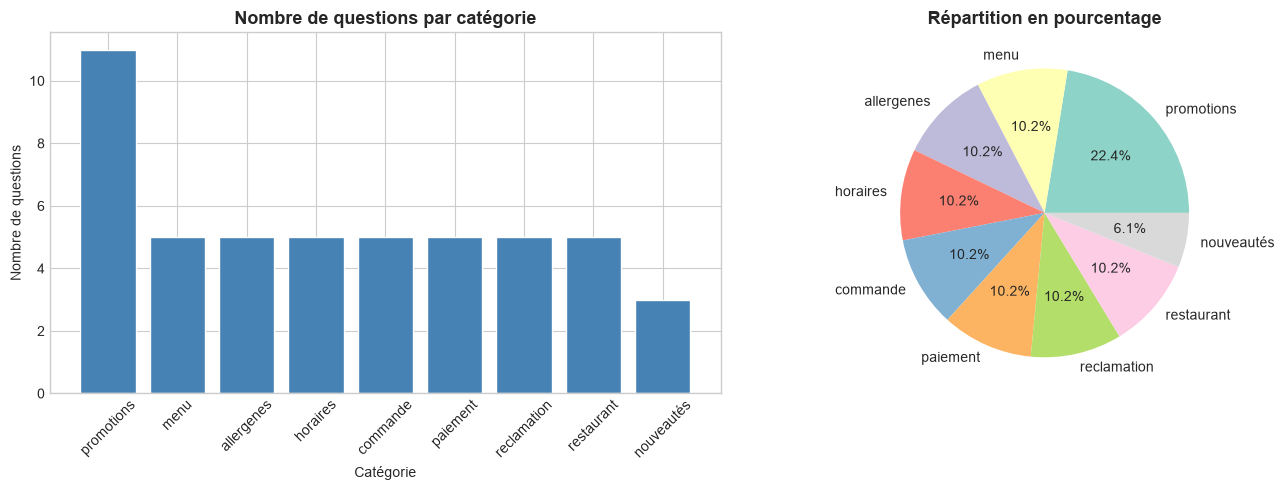

categorie
promotions     11
menu            5
allergenes      5
horaires        5
commande        5
paiement        5
reclamation     5
restaurant      5
nouveautés      3
Name: count, dtype: int64


In [10]:
cat_counts = df['categorie'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Nombre de questions par catégorie', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre de questions')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=plt.cm.Set3.colors[:len(cat_counts)])
axes[1].set_title('Répartition en pourcentage', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/distribution_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print(cat_counts)

## 3. Longueur des questions et réponses

In [11]:
df['longueur_question'] = df['question'].apply(len)
df['longueur_reponse'] = df['reponse'].apply(len)
df['nb_mots_question'] = df['question'].apply(lambda x: len(x.split()))
df['nb_mots_reponse'] = df['reponse'].apply(lambda x: len(x.split()))

print('=== Statistiques sur les questions ===')
print(df[['longueur_question', 'nb_mots_question']].describe().round(1))
print()
print('=== Statistiques sur les réponses ===')
print(df[['longueur_reponse', 'nb_mots_reponse']].describe().round(1))

=== Statistiques sur les questions ===
       longueur_question  nb_mots_question
count               49.0              49.0
mean                43.7               7.8
std                  8.8               1.6
min                 28.0               5.0
25%                 37.0               7.0
50%                 44.0               8.0
75%                 49.0               9.0
max                 70.0              11.0

=== Statistiques sur les réponses ===
       longueur_reponse  nb_mots_reponse
count              49.0             49.0
mean              110.9             16.7
std                26.6              4.4
min                55.0              9.0
25%                95.0             14.0
50%               109.0             16.0
75%               126.0             19.0
max               178.0             30.0


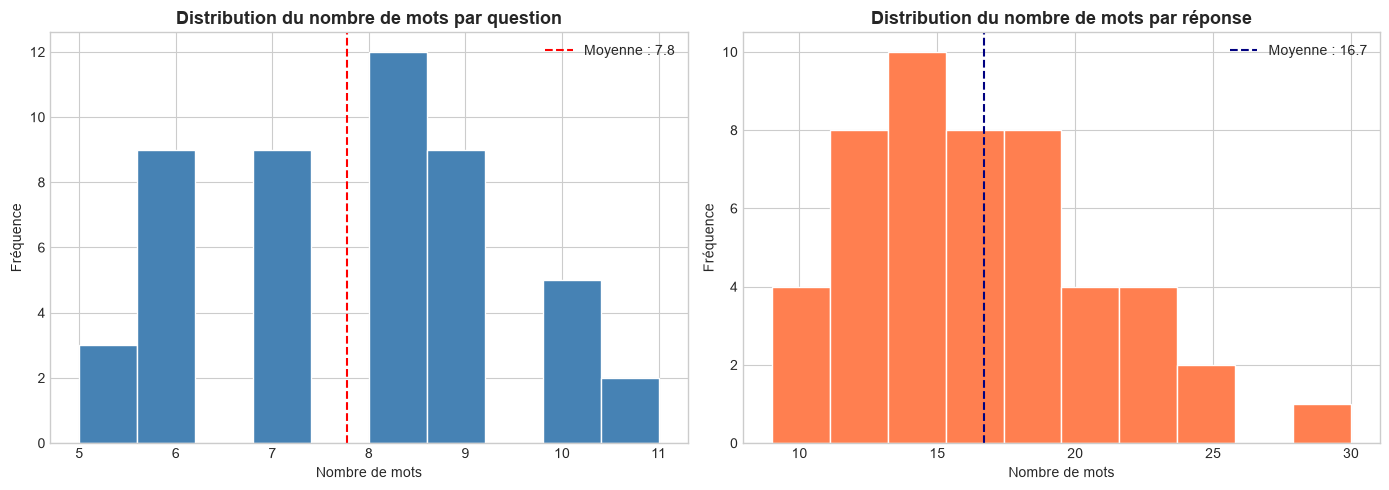

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['nb_mots_question'], bins=10, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du nombre de mots par question', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df['nb_mots_question'].mean(), color='red', linestyle='--',
                label=f'Moyenne : {df["nb_mots_question"].mean():.1f}')
axes[0].legend()

axes[1].hist(df['nb_mots_reponse'], bins=10, color='coral', edgecolor='white')
axes[1].set_title('Distribution du nombre de mots par réponse', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(df['nb_mots_reponse'].mean(), color='navy', linestyle='--',
                label=f'Moyenne : {df["nb_mots_reponse"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/distribution_longueurs.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Longueur moyenne des réponses par catégorie

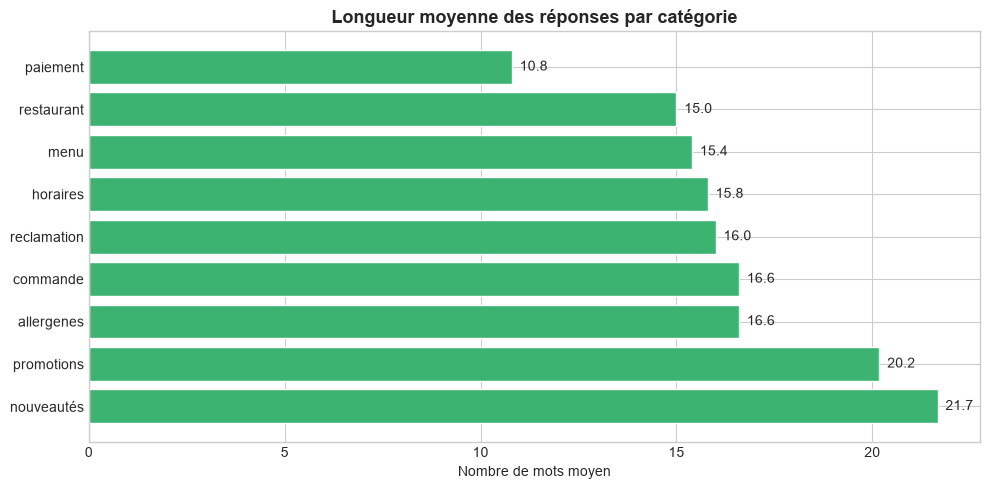

In [13]:
moy_cat = df.groupby('categorie')['nb_mots_reponse'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(moy_cat.index, moy_cat.values, color='mediumseagreen', edgecolor='white')
ax.set_title('Longueur moyenne des réponses par catégorie', fontsize=13, fontweight='bold')
ax.set_xlabel('Nombre de mots moyen')
for i, v in enumerate(moy_cat.values):
    ax.text(v + 0.2, i, f'{v:.1f}', va='center')

plt.tight_layout()
plt.savefig('../data/longueur_par_categorie.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Synthèse

In [14]:
print('=== SYNTHÈSE DU DATASET ===')
print(f'Total questions        : {len(df)}')
print(f'Catégories             : {df["categorie"].nunique()}')
print(f'Catégorie dominante    : {cat_counts.idxmax()} ({cat_counts.max()} questions)')
print(f'Catégorie minoritaire  : {cat_counts.idxmin()} ({cat_counts.min()} questions)')
print(f'Longueur moy. question : {df["nb_mots_question"].mean():.1f} mots')
print(f'Longueur moy. réponse  : {df["nb_mots_reponse"].mean():.1f} mots')
print(f'Valeurs manquantes     : {df.isnull().sum().sum()}')

=== SYNTHÈSE DU DATASET ===
Total questions        : 49
Catégories             : 9
Catégorie dominante    : promotions (11 questions)
Catégorie minoritaire  : nouveautés (3 questions)
Longueur moy. question : 7.8 mots
Longueur moy. réponse  : 16.7 mots
Valeurs manquantes     : 0
